# 📊 Instagram Performance Analysis — Travel Mex Tours
## Notebook 01: Exploratory Data Analysis (EDA)

**Author:** Maria Garcia Sehara  
**Project:** Social Media Analytics — Travel Mex Tours  
**Platform:** Instagram  

---

### Objective
Explore Instagram Insights data to uncover patterns in engagement, identify the best times to post, and generate actionable recommendations for the agency.

### Contents
1. Environment Setup & Imports
2. Load Data
3. Data Overview & Quality Check
4. Engagement Rate Analysis
5. Best Day & Hour to Post
6. Content Type Performance
7. Reach vs Engagement Correlation
8. Engagement Breakdown
9. Monthly Trend
10. Key Findings & Recommendations


## 1. Environment Setup & Imports

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")

# Make src/ importable from the notebooks/instagram/ directory
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

# ── Style ──────────────────────────────────────────────────────────────────
BRAND_BLUE   = "#1877F2"
BRAND_PURPLE = "#833AB4"
BRAND_PINK   = "#E1306C"
PALETTE      = [BRAND_BLUE, BRAND_PURPLE, BRAND_PINK, "#FCAF45", "#FD1D1D"]

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.figsize":    (12, 5),
    "axes.titlesize":    14,
    "axes.labelsize":    12,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR     = Path("../../data/instagram/")
FIGURES_PATH = Path("../../outputs/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

# Automatically picks the most recently modified CSV in the folder
csv_files = sorted(DATA_DIR.glob("*.csv"), key=lambda f: f.stat().st_mtime, reverse=True)

if not csv_files:
    raise FileNotFoundError(f"❌ No CSV files found in {DATA_DIR} — please add your Instagram export there.")

DATA_PATH = csv_files[0]
print("✅ Setup complete")
print(f"   Using file   : {DATA_PATH.name}")
print(f"   Figures path : {FIGURES_PATH}")


✅ Setup complete
   Using file   : InstagramData.csv
   Figures path : ../../outputs/figures


## 2. Load Data

In [2]:
from load_data import load_instagram_csv
from preprocessing import preprocess_df

# Load raw data
df_raw = load_instagram_csv(DATA_PATH)
print(f"Raw shape: {df_raw.shape}")
df_raw.head(3)


File successfully loaded: InstagramData.csv
   Shape: (125, 18)
   Detected content type: UNKNOWN
Raw shape: (125, 18)


,post_id,account_id,account_username,account_name,description,duration_sec,publish_time,permalink,post_type,data_comment,date,views,reach,likes,shares,follows,comments,saves
0,1.80109E+16,1.78414E+16,travelmextours,Agencia De Viaje En Miami,🌏⛵ ¡Embárcate en la aventura de tu vida por As...,40.0,2025-07-31 09:02:00,https://www.instagram.com/reel/DMxzN5KMCG3/,IG reel,NaN,NaT,226.0,192.0,10.0,1.0,0.0,2.0,1.0
1,1.80145E+16,1.78414E+16,travelmextours,Agencia De Viaje En Miami,🇮🇹🌟 ¡Italia te llama!\nDescubre la grandeza de...,0.0,2025-07-30 09:00:00,https://www.instagram.com/p/DMvOSF-vqPn/,IG carousel,NaN,NaT,94.0,36.0,4.0,1.0,0.0,0.0,0.0
2,1.80209E+16,1.78414E+16,travelmextours,Agencia De Viaje En Miami,🌍 No es solo un viaje… es la vuelta al mundo q...,0.0,2025-07-29 09:00:00,https://www.instagram.com/p/DMspd67JRqv/,IG carousel,NaN,NaT,101.0,32.0,4.0,2.0,0.0,0.0,1.0


In [3]:
# Preprocess
df, meta = preprocess_df(df_raw)

print("\n📋 Key columns detected:")
for k, v in meta.items():
    if k.endswith("_col") and v:
        print(f"   {k:30s} → {v}")


✅ Preprocessing completed!
   → Date column        : publish_time
   → ER calculated via  : REACH
   → Avg ER             : 15.36%
   → Date range         : 2025-05-01 → 2025-11-05

📋 Key columns detected:
   date_col                       → publish_time
   reach_col                      → reach
   views_col                      → views
   likes_col                      → likes
   comments_col                   → comments
   saves_col                      → saves
   shares_col                     → shares
   follows_col                    → follows
   type_col                       → post_type
   duration_col                   → duration_sec
   engagement_col                 → total_engagements
   engagement_rate_col            → engagement_rate_pct


## 3. Data Overview & Quality Check

In [4]:
print(f"Total posts analyzed : {len(df)}")
print(f"Date range           : {meta['date_range_start']} → {meta['date_range_end']}")
print(f"Avg Engagement Rate  : {meta['avg_engagement_rate']}%")
print(f"ER calculated via    : {meta['engagement_denominator'].upper()}")
print()

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing.to_string())


Total posts analyzed : 125
Date range           : 2025-05-01 → 2025-11-05
Avg Engagement Rate  : 15.36%
ER calculated via    : REACH

Missing values per column:
date                      125
data_comment              121
weekday                     4
duration_sec                4
publish_time                4
hour                        4
month                       4
reach                       2
like_rate_on_views_pct      2
permalink                   2
description                 2
account_name                2
account_username            2
post_type                   2
comments_per_like           2
views                       2
share_rate_pct              2
engagement_rate_pct         2
follows                     2
shares                      2
saves                       2
comments                    2
likes                       2
save_rate_pct               2


In [5]:
# Data types and sample
df.dtypes.to_frame("dtype").T


,publish_time,weekday,hour,month,engagement_rate_pct,total_engagements,reach,views,likes,comments,...,duration_sec,post_id,account_id,account_username,account_name,description,permalink,data_comment,date,is_weekend
dtype,datetime64[ns],object,float64,object,float64,float64,float64,float64,float64,float64,...,float64,object,object,object,object,object,object,object,datetime64[ns],bool


In [6]:
# Summary statistics
er_col = meta["engagement_rate_col"]
numeric_summary = df.select_dtypes(include="number").describe().round(2)
numeric_summary


,hour,engagement_rate_pct,total_engagements,reach,views,likes,comments,saves,shares,follows,save_rate_pct,share_rate_pct,comments_per_like,like_rate_on_views_pct,duration_sec
count,121.00,123.00,125.00,123.00,123.00,123.00,123.00,123.00,123.00,123.00,123.00,123.00,123.00,123.00,121.00
mean,9.83,15.36,5.46,47.89,98.49,4.73,0.15,0.22,0.44,0.01,0.41,1.00,0.02,5.56,10.65
std,2.09,7.56,3.22,49.97,58.31,2.34,0.61,0.50,0.88,0.09,1.12,2.29,0.10,2.87,22.05
min,7.00,0.80,0.00,13.00,22.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.71,0.00
25%,9.00,10.00,3.00,22.00,62.50,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,3.69,0.00
50%,9.00,14.29,5.00,31.00,84.00,4.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,0.00
75%,10.00,20.55,7.00,57.00,113.00,6.00,0.00,0.00,1.00,0.00,0.00,0.34,0.00,7.05,12.00
max,17.00,38.46,18.00,392.00,440.00,15.00,4.00,2.00,4.00,1.00,7.14,11.11,0.80,18.18,90.00


## 4. Engagement Rate Analysis

> **Industry benchmark for 1k–10k follower accounts:** 3–6% (avg 5%) — Source: RivalIQ 2025
> Travel Mex has **2,608 followers** — this is the correct reference group.


In [7]:
er_col = meta["engagement_rate_col"]
er     = df[er_col].dropna()

# IQR outlier detection
Q1, Q3 = er.quantile(0.25), er.quantile(0.75)
IQR    = Q3 - Q1
lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df[er_col] < lo) | (df[er_col] > hi)]

print(f"Mean ER           : {er.mean():.2f}%")
print(f"Median ER         : {er.median():.2f}%")
print(f"Std Dev           : {er.std():.2f}%")
print(f"Min / Max         : {er.min():.2f}% / {er.max():.2f}%")
print(f"IQR bounds        : {lo:.2f}% → {hi:.2f}%")
print(f"Outliers detected : {len(outliers)} posts ({len(outliers)/len(df)*100:.1f}%)")
print(f"Beats benchmark?  : {'✅ YES' if er.mean() > 3.5 else '⚠️ Below 3.5%'}")


Mean ER           : 15.36%
Median ER         : 14.29%
Std Dev           : 7.56%
Min / Max         : 0.80% / 38.46%
IQR bounds        : -5.82% → 36.37%
Outliers detected : 1 posts (0.8%)
Beats benchmark?  : ✅ YES


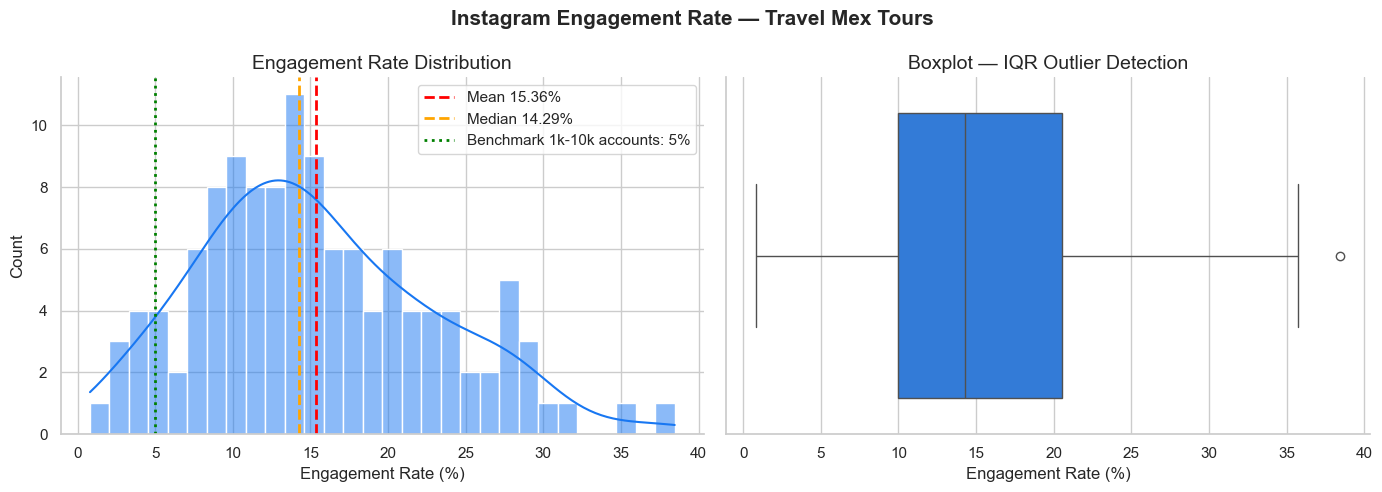

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
sns.histplot(er, bins=30, kde=True, color=BRAND_BLUE, ax=ax1)
ax1.axvline(er.mean(),   color="red",    ls="--", lw=2, label=f"Mean {er.mean():.2f}%")
ax1.axvline(er.median(), color="orange", ls="--", lw=2, label=f"Median {er.median():.2f}%")
ax1.axvline(5.0,         color="green",  ls=":",  lw=2, label="Benchmark 1k-10k accounts: 5%")
ax1.set_title("Engagement Rate Distribution")
ax1.set_xlabel("Engagement Rate (%)")
ax1.legend()

# Boxplot
sns.boxplot(x=er, color=BRAND_BLUE, ax=ax2)
ax2.set_title("Boxplot — IQR Outlier Detection")
ax2.set_xlabel("Engagement Rate (%)")

plt.suptitle("Instagram Engagement Rate — Travel Mex Tours", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_PATH / "01_engagement_rate.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Best Day & Hour to Post

⭐ Best day to post : Monday (16.67% avg ER)


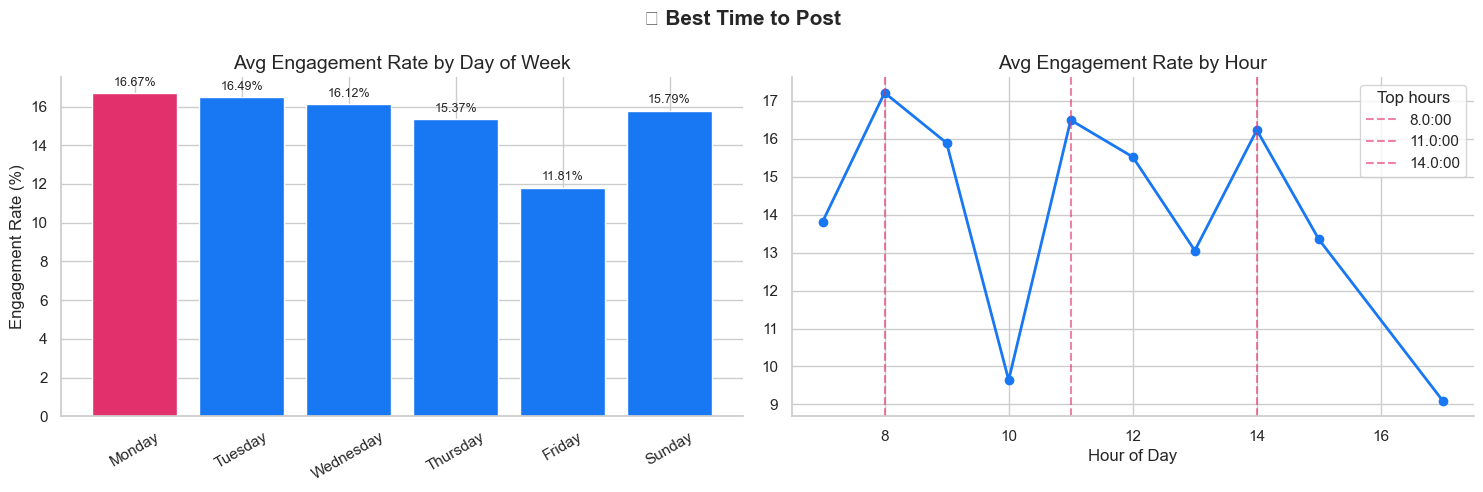

In [9]:
WEEKDAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

if "weekday" in df.columns:
    day_avg  = df.groupby("weekday")[er_col].mean().reindex(
        [d for d in WEEKDAY_ORDER if d in df["weekday"].unique()]
    )
    best_day = day_avg.idxmax()
    print(f"⭐ Best day to post : {best_day} ({day_avg[best_day]:.2f}% avg ER)")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    colors = [BRAND_PINK if d == best_day else BRAND_BLUE for d in day_avg.index]
    bars = axes[0].bar(day_avg.index, day_avg.values, color=colors)
    axes[0].bar_label(bars, fmt="%.2f%%", padding=3, fontsize=9)
    axes[0].set_title("Avg Engagement Rate by Day of Week")
    axes[0].set_ylabel("Engagement Rate (%)")
    axes[0].tick_params(axis="x", rotation=30)

    if "hour" in df.columns:
        hour_avg  = df.groupby("hour")[er_col].mean().sort_index()
        top3      = hour_avg.nlargest(3).index.tolist()
        axes[1].plot(hour_avg.index, hour_avg.values, marker="o", color=BRAND_BLUE, lw=2)
        for h in top3:
            axes[1].axvline(h, color=BRAND_PINK, ls="--", alpha=0.6, label=f"{h}:00")
        axes[1].set_title("Avg Engagement Rate by Hour")
        axes[1].set_xlabel("Hour of Day")
        axes[1].legend(title="Top hours")

    plt.suptitle("📅 Best Time to Post", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / "02_best_time_to_post.png", dpi=150, bbox_inches="tight")
    plt.show()


## 6. Content Type Performance

⭐ Best content type : IG carousel


,Avg ER,Median ER,Posts,Std
post_type,,,,
IG carousel,17.80,16.95,72,7.28
IG image,16.50,14.29,11,7.80
IG reel,10.07,9.48,38,5.12
Post type,NaN,NaN,0,NaN


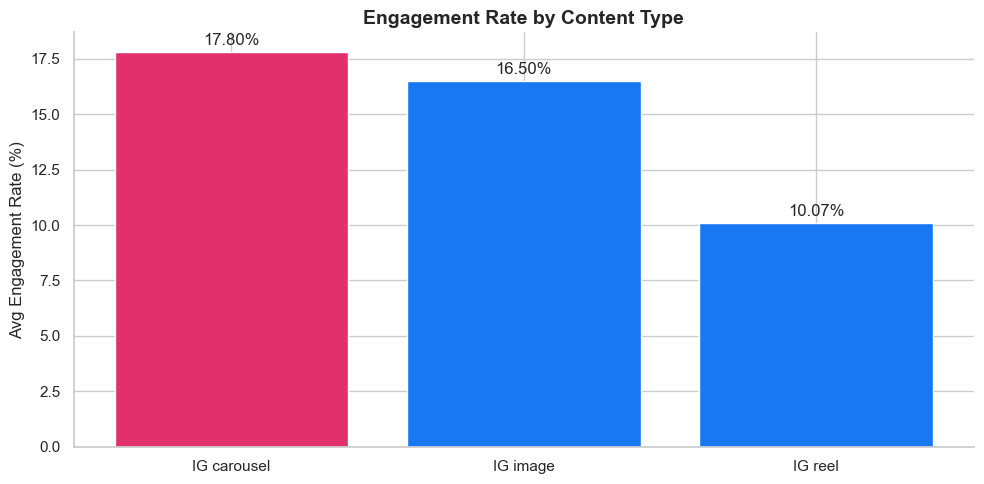

In [10]:
type_col = meta.get("type_col")

if type_col and type_col in df.columns:
    type_stats = (
        df.groupby(type_col)[er_col]
          .agg(["mean","median","count","std"])
          .rename(columns={"mean":"Avg ER","median":"Median ER","count":"Posts","std":"Std"})
          .sort_values("Avg ER", ascending=False)
          .round(2)
    )
    best_type = type_stats["Avg ER"].idxmax()
    print(f"⭐ Best content type : {best_type}")
    display(type_stats)

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = [BRAND_PINK if t == best_type else BRAND_BLUE for t in type_stats.index]
    bars   = ax.bar(type_stats.index, type_stats["Avg ER"], color=colors)
    ax.bar_label(bars, fmt="%.2f%%", padding=3)
    ax.set_title("Engagement Rate by Content Type", fontsize=14, fontweight="bold")
    ax.set_ylabel("Avg Engagement Rate (%)")
    plt.tight_layout()
    plt.savefig(FIGURES_PATH / "03_content_type.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("⚠️ No content type column found in this dataset.")


## 7. Reach vs Engagement Rate

Pearson correlation (reach vs ER): -0.484


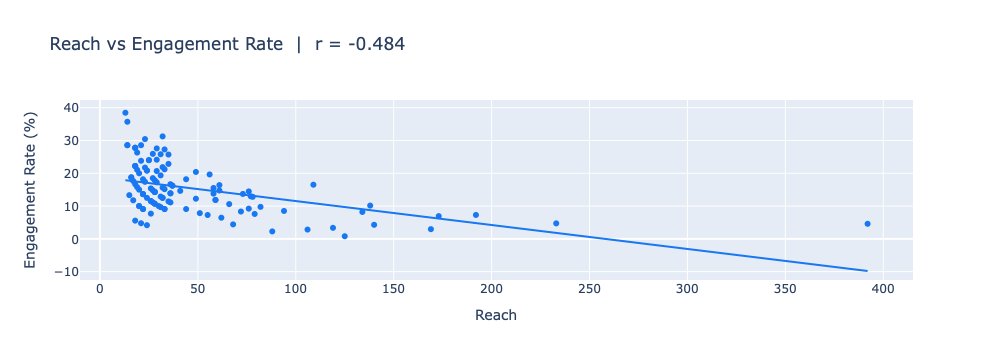

In [11]:
denom_col = meta.get("reach_col") or meta.get("impressions_col") or meta.get("views_col")

if denom_col and denom_col in df.columns:
    plot_df = df[[denom_col, er_col]].dropna()
    corr    = plot_df[denom_col].corr(plot_df[er_col])
    print(f"Pearson correlation ({denom_col} vs ER): {corr:.3f}")

    fig = px.scatter(
        plot_df, x=denom_col, y=er_col,
        trendline="ols",
        labels={denom_col: denom_col.replace("_"," ").title(), er_col: "Engagement Rate (%)"},
        title=f"{denom_col.replace('_',' ').title()} vs Engagement Rate  |  r = {corr:.3f}",
        color_discrete_sequence=[BRAND_BLUE]
    )
    fig.show()


## 8. Engagement Breakdown

Total interactions:
   Likes       : 582
   Comments    : 18
   Saves       : 27
   Shares      : 54


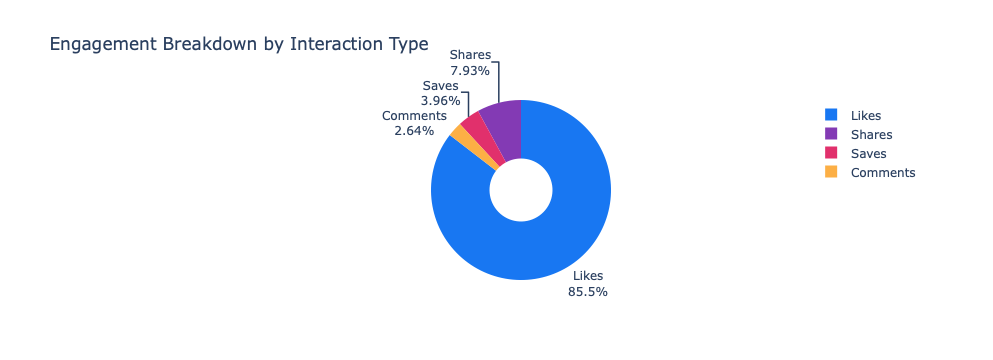

In [13]:
breakdown = {
    "Likes":    meta.get("likes_col"),
    "Comments": meta.get("comments_col"),
    "Saves":    meta.get("saves_col"),
    "Shares":   meta.get("shares_col"),
}
breakdown = {k: v for k, v in breakdown.items() if v and v in df.columns}

if breakdown:
    totals = {k: int(df[v].sum()) for k, v in breakdown.items()}
    print("Total interactions:")
    for k, v in totals.items():
        print(f"   {k:12s}: {v:,}")

    fig = px.pie(
        values=list(totals.values()),
        names=list(totals.keys()),
        title="Engagement Breakdown by Interaction Type",
        color_discrete_sequence=PALETTE,
        hole=0.35
    )
    fig.update_traces(textposition="outside", textinfo="percent+label")
    fig.show()


## 9. Monthly Engagement Rate Trend

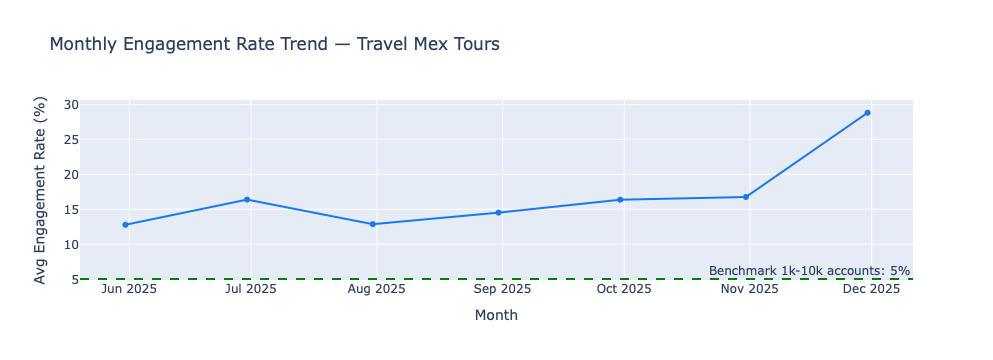

In [14]:
date_col = meta.get("date_col")

if date_col and pd.api.types.is_datetime64_any_dtype(df[date_col]):
    monthly = df.set_index(date_col)[er_col].resample("ME").mean().dropna()

    if len(monthly) >= 2:
        fig = px.line(
            x=monthly.index, y=monthly.values,
            markers=True,
            labels={"x": "Month", "y": "Avg Engagement Rate (%)"},
            title="Monthly Engagement Rate Trend — Travel Mex Tours",
            color_discrete_sequence=[BRAND_BLUE]
        )
        fig.add_hline(y=5.0, line_dash="dash", line_color="green",
                      annotation_text="Benchmark 1k-10k accounts: 5%")
        fig.show()
    else:
        print("⚠️ Not enough months for a trend chart.")
else:
    print("⚠️ No date column found.")


## 10. Key Findings & Recommendations

In [15]:
er = df[er_col].dropna()

print("=" * 60)
print("  KEY FINDINGS — TRAVEL MEX TOURS INSTAGRAM")
print("=" * 60)
print(f"\n📊 PERFORMANCE")
print(f"   Average ER       : {er.mean():.2f}%")
print(f"   Industry avg     : 1.8–3.5%")
print(f"   Performance      : {'✅ Above benchmark' if er.mean() > 3.5 else '⚠️ Below benchmark'}")

if "weekday" in df.columns:
    best_day = df.groupby("weekday")[er_col].mean().idxmax()
    print(f"\n📅 TIMING")
    print(f"   Best day to post : {best_day}")
    if "hour" in df.columns:
        top3 = df.groupby("hour")[er_col].mean().nlargest(3).index.tolist()
        print(f"   Best hours       : {', '.join([str(h)+':00' for h in top3])}")

type_col = meta.get("type_col")
if type_col and type_col in df.columns:
    best_type = df.groupby(type_col)[er_col].mean().idxmax()
    print(f"\n🎬 CONTENT")
    print(f"   Best content type: {best_type}")

print(f"\n🎯 RECOMMENDATIONS")
print(f"   1. Post consistently on {best_day if 'weekday' in df.columns else 'your best day'}")
print(f"   2. Prioritize top-performing content formats")
print(f"   3. Study the {len(outliers)} viral posts and replicate their patterns")
print(f"   4. Monitor monthly trend to catch drops early")
print("=" * 60)
print("\n→ Next: Notebook 02 — Hypothesis Testing")


  KEY FINDINGS — TRAVEL MEX TOURS INSTAGRAM

📊 PERFORMANCE
   Average ER       : 15.36%
   Industry avg     : 1.8–3.5%
   Performance      : ✅ Above benchmark

📅 TIMING
   Best day to post : Monday
   Best hours       : 8.0:00, 11.0:00, 14.0:00

🎬 CONTENT
   Best content type: IG carousel

🎯 RECOMMENDATIONS
   1. Post consistently on Monday
   2. Prioritize top-performing content formats
   3. Study the 1 viral posts and replicate their patterns
   4. Monitor monthly trend to catch drops early

→ Next: Notebook 02 — Hypothesis Testing
